In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import date, timedelta
from typing import Optional

from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

In [3]:
# Much data wow
data = pl.read_parquet('data/train.parquet')
print(data.shape)

(30631006, 18)


In [4]:
# Sanity checks
print(data.dtypes)
print(data.null_count()) 

[Date, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Float64, Float64, Int64, Int64, Float64, Int64]
shape: (1, 18)
┌────────────┬─────────┬────────┬─────┬───┬─────────┬────────┬─────┬──────────┐
│ event_date ┆ user_id ┆ search ┆ cat ┆ … ┆ to_cart ┆ to_ord ┆ gmv ┆ searches │
│ ---        ┆ ---     ┆ ---    ┆ --- ┆   ┆ ---     ┆ ---    ┆ --- ┆ ---      │
│ u32        ┆ u32     ┆ u32    ┆ u32 ┆   ┆ u32     ┆ u32    ┆ u32 ┆ u32      │
╞════════════╪═════════╪════════╪═════╪═══╪═════════╪════════╪═════╪══════════╡
│ 0          ┆ 0       ┆ 0      ┆ 0   ┆ … ┆ 0       ┆ 0      ┆ 0   ┆ 0        │
└────────────┴─────────┴────────┴─────┴───┴─────────┴────────┴─────┴──────────┘


In [5]:
# A sneak peek into the data itself
print(data["event_date"].min(), "to", data["event_date"].max())
data.head(5)

2025-01-01 to 2026-02-13


event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,i64
2025-06-16,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,2
2025-06-22,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-08,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2025-08-18,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-23,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1


### What is up with the overall data timeline?

Let's aggregate a few daily global stats and plot them.

In [6]:
daily_agg = (
    data.group_by("event_date")
    .agg(
        pl.len().alias("n_users"),
        pl.sum("gmv").alias("gmv_sum"),
        pl.sum("to_cart").alias("to_cart_sum"),
        pl.sum("to_ord").alias("to_ord_sum"),
        pl.sum("searches").alias("searches_sum"),
    )
    .sort("event_date")
)

daily_agg.head()

event_date,n_users,gmv_sum,to_cart_sum,to_ord_sum,searches_sum
date,u32,f64,i64,i64,i64
2025-01-01,43516,374066.469016,38548,8827,136443
2025-01-02,52556,489227.996022,51779,12381,174063
2025-01-03,53609,473332.477438,51388,12340,175456
2025-01-04,54882,450219.389198,54055,12785,182234
2025-01-05,55531,465926.986665,54809,12893,184256


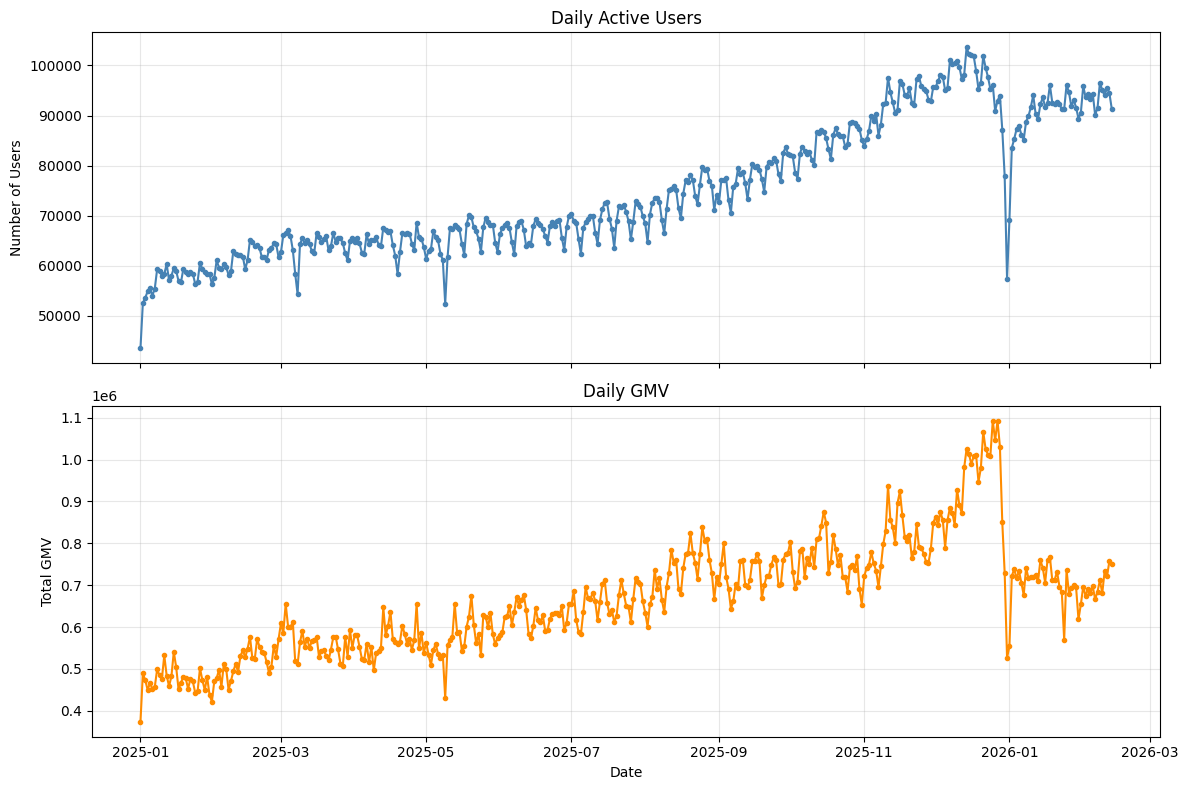

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Active users
axes[0].plot(daily_agg["event_date"], daily_agg["n_users"], marker=".", linestyle="-", color="steelblue")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Daily Active Users")
axes[0].grid(True, alpha=0.3)

# Total GMV
axes[1].plot(daily_agg["event_date"], daily_agg["gmv_sum"], marker=".", linestyle="-", color="darkorange")
axes[1].set_ylabel("Total GMV")
axes[1].set_title("Daily GMV")
axes[1].grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

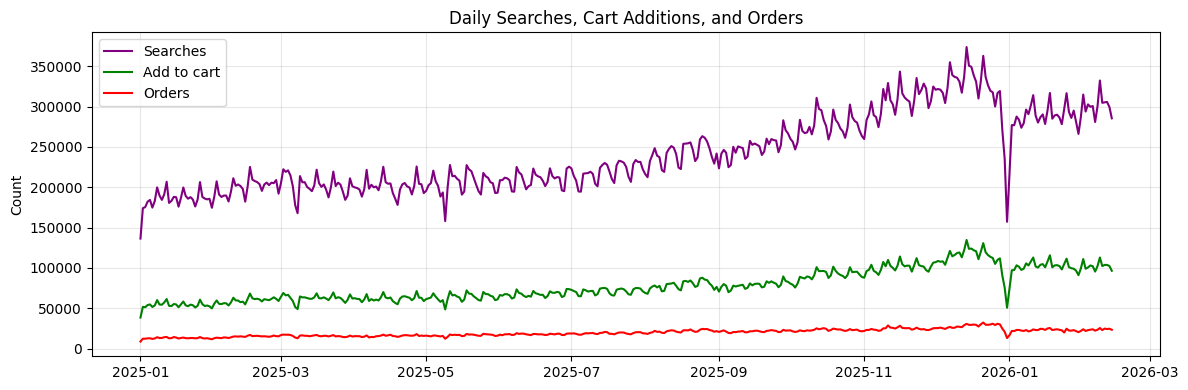

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(daily_agg["event_date"], daily_agg["searches_sum"], label="Searches", color="purple")
plt.plot(daily_agg["event_date"], daily_agg["to_cart_sum"], label="Add to cart", color="green")
plt.plot(daily_agg["event_date"], daily_agg["to_ord_sum"], label="Orders", color="red")
plt.legend()
plt.title("Daily Searches, Cart Additions, and Orders")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

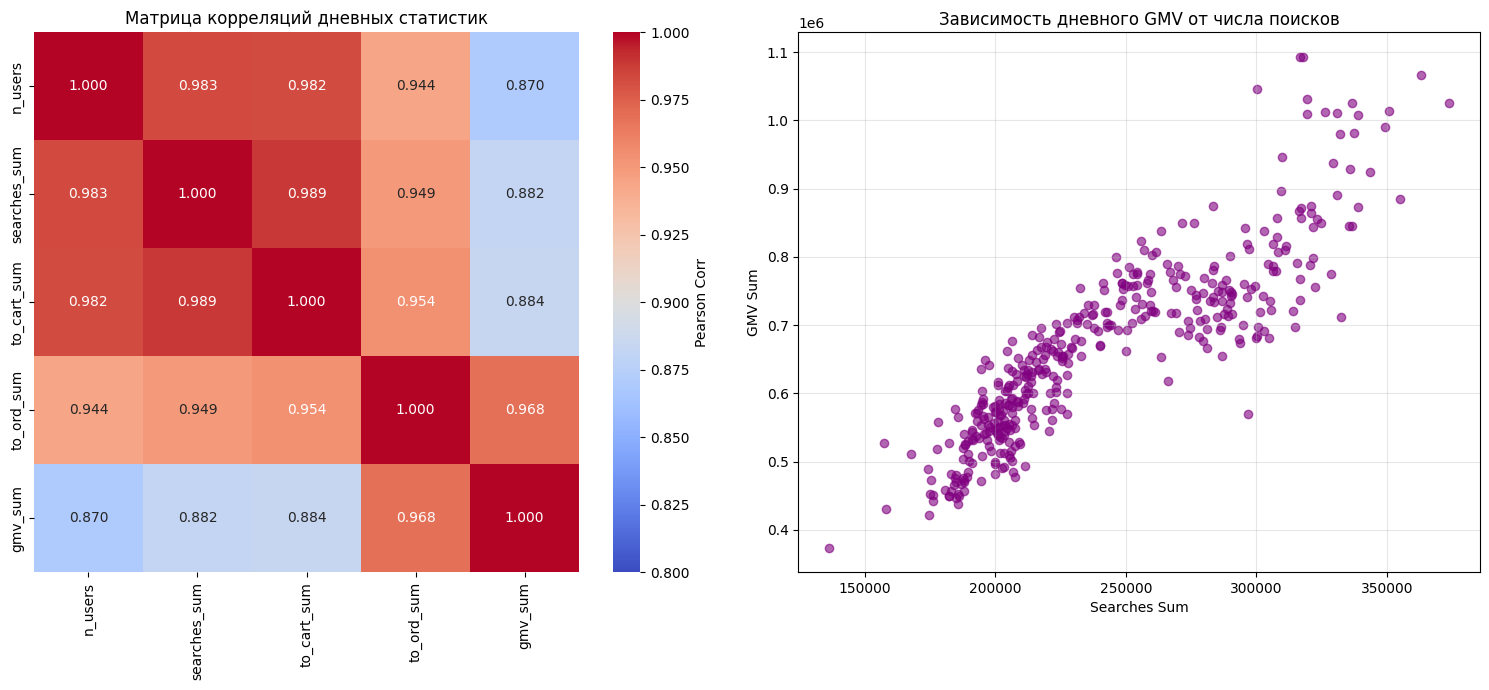

--- Ключевые корреляции ---
Корреляция Searches -> Cart:   0.9886
Корреляция Cart -> Orders:     0.9539
Корреляция Orders -> GMV:      0.9683


In [9]:
import seaborn as sns

# 1. Корреляции между дневными показателями
cols = ["n_users", "searches_sum", "to_cart_sum", "to_ord_sum", "gmv_sum"]
daily_df = daily_agg.to_pandas()
corr_matrix = daily_df[cols].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Тепловая карта корреляций
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=0.8, vmax=1.0, ax=axes[0], cbar_kws={'label': 'Pearson Corr'})
axes[0].set_title("Матрица корреляций дневных статистик", fontsize=12)

# Связь Поиски vs Заказы / GMV
axes[1].scatter(daily_df["searches_sum"], daily_df["gmv_sum"], color="purple", alpha=0.6, label="GMV vs Searches")
axes[1].set_xlabel("Searches Sum")
axes[1].set_ylabel("GMV Sum")
axes[1].set_title("Зависимость дневного GMV от числа поисков", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Печать ключевых выводов по корреляциям
print("--- Ключевые корреляции ---")
print(f"Корреляция Searches -> Cart:   {corr_matrix.loc['searches_sum', 'to_cart_sum']:.4f}")
print(f"Корреляция Cart -> Orders:     {corr_matrix.loc['to_cart_sum', 'to_ord_sum']:.4f}")
print(f"Корреляция Orders -> GMV:      {corr_matrix.loc['to_ord_sum', 'gmv_sum']:.4f}")


Всего юзеров: 250,000
Юзеров без трат (GMV = 0): 30,832 (12.33%)

Квантили трат (GMV) среди ВСЕХ пользователей:
0.25      73.759539
0.50     388.192308
0.75    1210.388731
0.90    2764.382220
0.95    4305.052927
0.99    9680.499806
Name: total_gmv, dtype: float64


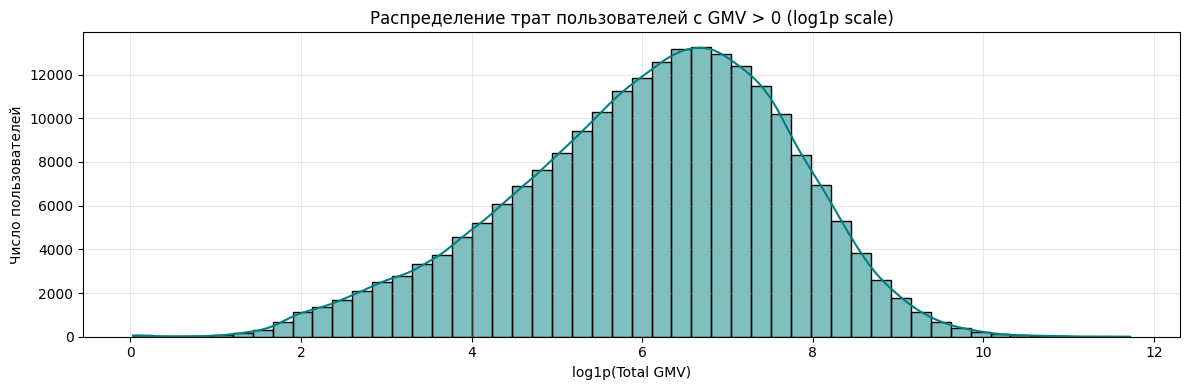

In [10]:
# 2. Агрегация показателей по пользователям
user_summary = (
    data.group_by("user_id")
    .agg(
        pl.sum("gmv").alias("total_gmv"),
        pl.len().alias("active_days"),
        pl.sum("searches").alias("total_searches"),
        pl.sum("to_ord").alias("total_orders"),
        pl.max("gmv").alias("max_single_day_gmv")
    )
)

user_df = user_summary.to_pandas()

# Считаем пользователей с 0 трат
zero_spend_count = (user_df["total_gmv"] == 0).sum()
total_users = len(user_df)

print(f"Всего юзеров: {total_users:,}")
print(f"Юзеров без трат (GMV = 0): {zero_spend_count:,} ({zero_spend_count / total_users * 100:.2f}%)")
print("\nКвантили трат (GMV) среди ВСЕХ пользователей:")
print(user_df["total_gmv"].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

# График распределения трат (в логарифмическом масштабе log1p)
plt.figure(figsize=(12, 4))
sns.histplot(np.log1p(user_df[user_df["total_gmv"] > 0]["total_gmv"]), bins=50, kde=True, color="teal")
plt.title("Распределение трат пользователей с GMV > 0 (log1p scale)")
plt.xlabel("log1p(Total GMV)")
plt.ylabel("Число пользователей")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


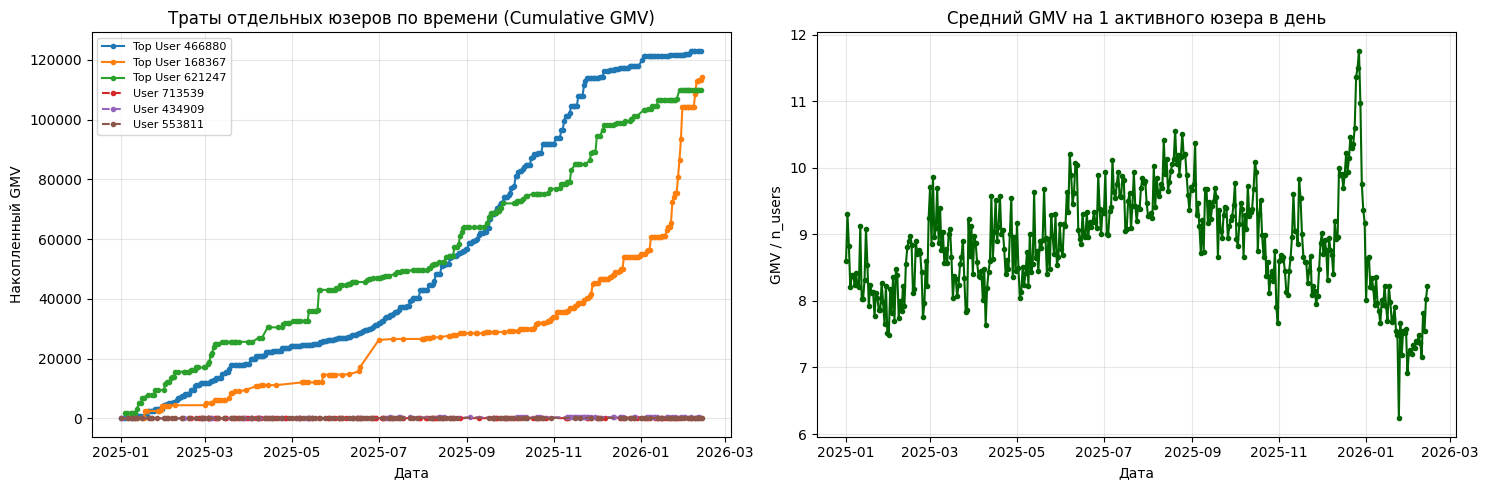

In [11]:
# 3. Траты отдельных юзеров во времени

# Выберем 3 категории юзеров: 3 топ-покупателя, 3 случайных платящих юзера
top_spenders = user_df.sort_values("total_gmv", ascending=False).head(3)["user_id"].tolist()
median_spenders = user_df[(user_df["total_gmv"] > 200) & (user_df["total_gmv"] < 500)].sample(3, random_state=42)["user_id"].tolist()

sample_user_ids = top_spenders + median_spenders

# Извлекаем историю по этим юзерам
sample_events = (
    data.filter(pl.col("user_id").is_in(sample_user_ids))
    .select(["event_date", "user_id", "gmv"])
    .sort(["user_id", "event_date"])
    .to_pandas()
)

# Кумулятивный GMV для каждого юзера
sample_events["cum_gmv"] = sample_events.groupby("user_id")["gmv"].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Кумулятивные траты выбранных юзеров
for uid in sample_user_ids:
    u_data = sample_events[sample_events["user_id"] == uid]
    label_text = f"Top User {uid}" if uid in top_spenders else f"User {uid}"
    ls = "-" if uid in top_spenders else "--"
    axes[0].plot(u_data["event_date"], u_data["cum_gmv"], label=label_text, linestyle=ls, marker=".")

axes[0].set_title("Траты отдельных юзеров по времени (Cumulative GMV)")
axes[0].set_ylabel("Накопленный GMV")
axes[0].set_xlabel("Дата")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# График 2: Средний GMV на 1 активного пользователя по дням
daily_avg_spend = daily_df["gmv_sum"] / daily_df["n_users"]
axes[1].plot(daily_df["event_date"], daily_avg_spend, color="darkgreen", marker=".")
axes[1].set_title("Средний GMV на 1 активного юзера в день")
axes[1].set_ylabel("GMV / n_users")
axes[1].set_xlabel("Дата")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Let's prepare some features 

- Not everyone has large RAM machines, especially in mid 2026
- So let's first build time-based features and targets...
- And build them batched by users
- After we're done we can work with extracted data directly as if it was a much simpler regression task

In [13]:
# keep extra features for homework
DEFAULT_AGGS = ["sum", "max", "std", "mean"]
DEFAULT_VALUE_COLS = ["gmv", "searches"]

# and a place to save our stuff
FEATURES_DIR = "data/v2/features"

# and choose a simple path for now
N_FOLDS = 4

# mind your RAM capabilities
# in case of really low-RAM machines mind that data is sorted by user (and by event_date later)
BATCH_SIZE = 50_000

# window = [anchor - start_off, anchor - end_off] (inclusive)
DEFAULT_WINDOWS = [
    ("30d", 29, 0),    # [t-29, t-0]  (includes anchor)
    ("60d", 59, 30),   # [t-59, t-30]
    ("90d", 89, 60),   # [t-89, t-60]
]

output_dir = Path(FEATURES_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

In [14]:
# Build key anchor dates for time-CV windows
def generate_cv_anchor_dates(
    data: pl.DataFrame,
    prediction_horizon_days: int = 30,
    stride_days: int = 14,
    min_history_days: int = 90,
    n_folds: Optional[int] = None,
) -> list[date]:
   
    min_date = data["event_date"].min()
    max_date = data["event_date"].max()

    latest_anchor = max_date - timedelta(days = prediction_horizon_days)
    earliest_anchor = min_date + timedelta(days = min_history_days - 1)

    # sanity check
    if latest_anchor < earliest_anchor:
        raise ValueError(
            f"Not enough data: need >={min_history_days + prediction_horizon_days - 1} days, "
            f"got {(max_date - min_date).days}."
        )

    n_steps = (latest_anchor - earliest_anchor).days // stride_days
    all_anchors = [latest_anchor - timedelta(days=i * stride_days) for i in range(n_steps + 1)]
    all_anchors = sorted(all_anchors)

    if n_folds is not None:
        if n_folds <= 0:
            raise ValueError("n_folds must be a positive integer.")
        return all_anchors[-n_folds:]
    
    return all_anchors

In [15]:
# helper feature recepies
# BYOF yet consider a tokenizer path instead :)
def _window_agg_exprs(
    anchor_val: date,
    windows: list[tuple[str, int, int]],
    value_cols: list[str],
    aggs: list[str],
) -> list[pl.Expr]:
    exprs = []
    for w_name, start_off, end_off in windows:
        w_start = anchor_val - timedelta(days = start_off)
        w_end = anchor_val - timedelta(days = end_off)
        mask = pl.col("event_date").is_between(w_start, w_end)

        for col in value_cols:
            for agg in aggs:
                if agg == "sum":
                    e = pl.when(mask).then(pl.col(col)).otherwise(0.0).sum()
                elif agg == "max":
                    e = pl.when(mask).then(pl.col(col)).otherwise(None).max()
                elif agg == "std":
                    e = pl.when(mask).then(pl.col(col)).otherwise(None).std()
                elif agg == "mean":
                    e = pl.when(mask).then(pl.col(col)).otherwise(None).mean()
                elif agg == "count":
                    e = pl.when(mask).then(1).otherwise(0).sum()
                else:
                    raise ValueError(f"Unknown agg: {agg}")
                exprs.append(e.alias(f"{col}_{agg}_{w_name}"))
    return exprs

In [16]:
# batch-ready features
# you can extract features right away, however it is likely to eat 40GB+ RAM
def generate_features(
    data: pl.DataFrame,
    anchor_dates: list[date],
    user_ids: Optional[list[int]] = None,
    value_cols: list[str] = DEFAULT_VALUE_COLS,
    windows: list[tuple[str, int, int]] = DEFAULT_WINDOWS,
    aggs: list[str] = DEFAULT_AGGS,
) -> pl.DataFrame:
    if user_ids is None:
        user_ids = data["user_id"].unique().sort().to_list()

    max_back = max(w[1] for w in windows)
    min_anchor, max_anchor = min(anchor_dates), max(anchor_dates)

    data_f = data.filter(
        pl.col("user_id").is_in(user_ids)
        & pl.col("event_date").is_between(
            min_anchor - timedelta(days=max_back),
            max_anchor,
        )
    )

    parts = []
    for a in anchor_dates:
        ad = data_f.filter(pl.col("event_date") >= a - timedelta(days=max_back))
        if len(ad) > 0:
            features = (
                ad.group_by("user_id")
                  .agg(_window_agg_exprs(a, windows, value_cols, aggs))
                  .with_columns(anchor_date=pl.lit(a))
            )
            parts.append(features)

    features_df = pl.concat(parts, how="diagonal_relaxed") if parts else pl.DataFrame()
    index_df = (
        pl.DataFrame({"anchor_date": anchor_dates})
        .join(pl.DataFrame({"user_id": user_ids}), how="cross")
    )
    result = index_df.join(features_df, on=["anchor_date", "user_id"], how="left")

    feature_cols = [c for c in result.columns if c not in ["anchor_date", "user_id"]]
    fill_exprs = [pl.col(c).fill_null(0.0) for c in feature_cols]

    
    return result.with_columns(fill_exprs)


In [17]:
# batch-ready target construction
def generate_targets(
    data: pl.DataFrame,
    anchor_dates: list[date],
    user_ids: Optional[list[int]] = None,
    horizon_days: int = 30,
    target_col: str = "gmv",
) -> pl.DataFrame:
    if user_ids is None:
        user_ids = data["user_id"].unique().sort().to_list()

    index_df = (
        pl.DataFrame({"anchor_date": anchor_dates})
        .join(pl.DataFrame({"user_id": user_ids}), how="cross")
    )

    parts = []
    for a in anchor_dates:
        t_start = a + timedelta(days=1)
        t_end   = a + timedelta(days=horizon_days)
        tgt = (
            data.filter(
                pl.col("user_id").is_in(user_ids)
                & pl.col("event_date").is_between(t_start, t_end)
            )
            .group_by("user_id")
            .agg(pl.col(target_col).sum().alias("target"))
            .with_columns(anchor_date=pl.lit(a))
        )
        parts.append(tgt)

    tgt_df = pl.concat(parts, how="diagonal_relaxed") if parts else pl.DataFrame()
    targets = index_df.join(tgt_df, on=["anchor_date", "user_id"], how="left")
    return targets.with_columns(pl.col("target").fill_null(0.0))

In [18]:
# prepare our time anchor structure
anchors_time_folds = generate_cv_anchor_dates(data, n_folds = N_FOLDS)
anchor_end_of_time = data["event_date"].max()

print(f"Time-CV folds   : {len(anchors_time_folds)} | {anchors_time_folds[0]} → "
    f"{anchors_time_folds[-1]} | stride = 14 days")
print(f"Prediction fold : {anchor_end_of_time} → predict [{anchor_end_of_time + timedelta(days = 1)}, "
    f"{anchor_end_of_time + timedelta(days = 30)}]")

Time-CV folds   : 4 | 2025-12-03 → 2026-01-14 | stride = 14 days
Prediction fold : 2026-02-13 → predict [2026-02-14, 2026-03-15]


In [19]:
# prepare for batch extraction
user_ids = data["user_id"].unique().sort().to_list()

n_users   = len(user_ids)
n_batches = (n_users + BATCH_SIZE - 1) // BATCH_SIZE
print(f"\n{n_users} users → {n_batches} batches per fold (batch_size = {BATCH_SIZE})\n")


250000 users → 5 batches per fold (batch_size = 50000)



### Let's roll

In [20]:
# 1. Process CV Folds 

for fold_idx, anchor in enumerate(anchors_time_folds):

    fold_name = f"fold_{fold_idx:02d}"
    fold_dir = output_dir / fold_name
    fold_dir.mkdir(parents=True, exist_ok=True)

    for batch in range(n_batches):
        current_batch = user_ids[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
        features = generate_features(data, [anchor], user_ids = current_batch)
        targets = generate_targets(data, [anchor], user_ids = current_batch,
                                horizon_days = 30)
            
        out_df = features.join(targets, on=["anchor_date", "user_id"], how="left")
        out_df = out_df.with_columns(pl.col("target").fill_null(0.0))
        out_df.write_parquet(fold_dir / f"batch_{batch:04d}.parquet")
            
    print(f"  Processed {fold_name} (anchor: {anchor})")

  Processed fold_00 (anchor: 2025-12-03)
  Processed fold_01 (anchor: 2025-12-17)
  Processed fold_02 (anchor: 2025-12-31)
  Processed fold_03 (anchor: 2026-01-14)


In [21]:
# 2. Process Final Prediction Fold

fold_dir = output_dir / "fold_end"
fold_dir.mkdir(parents=True, exist_ok=True)

for batch in range(n_batches):
    current_batch = user_ids[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
    feats = generate_features(data, [anchor_end_of_time], user_ids = current_batch)
    out_df = feats.with_columns(pl.lit(None).cast(pl.Float64).alias("target"))
    out_df.write_parquet(fold_dir / f"batch_{batch:04d}.parquet")
        
print(f"  Processed fold_last (anchor: {anchor_end_of_time})")

  Processed fold_last (anchor: 2026-02-13)


### Now on to ML

- Let's check what we are up for
- After that let's decide our next best plan of action

In [23]:
# safe clipped log1p RMSLE
def rmsle(y_true, y_pred):
    log_true = np.log1p(np.clip(y_true, 0, None))
    log_pred = np.log1p(np.clip(y_pred, 0, None))
    return np.sqrt(mean_squared_error(log_true, log_pred))

# small helper to read our processed feature folds
def read_fold(output_dir: str | Path, fold_name: str):
    pattern = str(Path(output_dir) / fold_name / "batch_*.parquet")
    return pl.read_parquet(pattern)

In [24]:
folds = []
for fold_idx, anchor in enumerate(anchors_time_folds):
    fold_name = f"fold_{fold_idx:02d}"
    fold_df = read_fold(FEATURES_DIR, fold_name)
    folds.append(fold_df)

Всего пользователей в fold_03: 250,000
Пользователей БЕЗ трат (GMV = 0): 114,835 (45.93%)
Пользователей С ТРАТАМИ (GMV > 0): 135,165 (54.07%)

Квантили GMV среди ВСЕХ пользователей:
   50.0%:       7.89
   75.0%:      70.52
   90.0%:     215.86
   95.0%:     383.46
   99.0%:    1040.14
   99.9%:    2933.56
  100.0%:   53746.95

Квантили GMV только среди ПОКУПАТЕЛЕЙ (GMV > 0):
   50.0%:      61.36
   75.0%:     159.68
   90.0%:     361.67
   95.0%:     587.47
   99.0%:    1396.32
   99.9%:    3609.81
  100.0%:   53746.95

Топ-5 максимальных трат (хвост): [53746.95081219 27521.4983558  21939.93141078 11639.20366257
 11062.25064831]


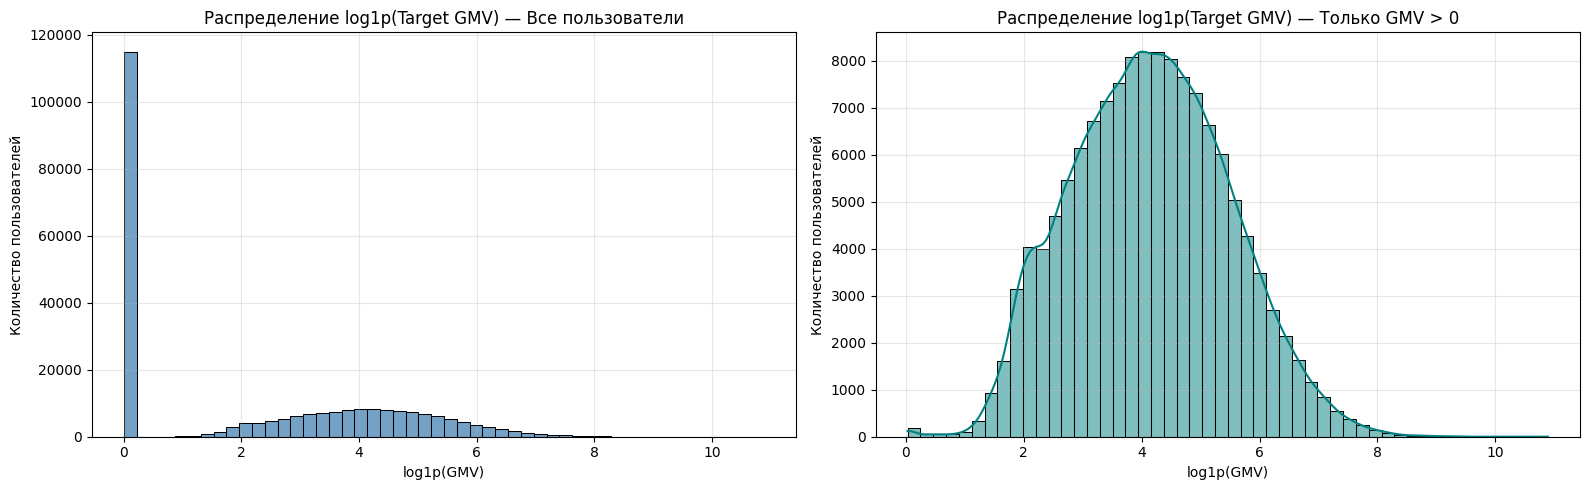

In [25]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Берём fold_03 из переменной folds (или читаем из папки)
try:
    fold_03 = folds[3]
except (NameError, IndexError):
    fold_03 = read_fold(FEATURES_DIR, "fold_03")

target = fold_03["target"].to_numpy()
total_users = len(target)
zero_count = (target == 0).sum()
pos_count = (target > 0).sum()

print("=" * 65)
print(f"Всего пользователей в fold_03: {total_users:,}")
print(f"Пользователей БЕЗ трат (GMV = 0): {zero_count:,} ({zero_count / total_users * 100:.2f}%)")
print(f"Пользователей С ТРАТАМИ (GMV > 0): {pos_count:,} ({pos_count / total_users * 100:.2f}%)")
print("=" * 65)

quantiles = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]

# 1. Квантили среди ВСЕХ пользователей
q_all = np.quantile(target, quantiles)
print("\nКвантили GMV среди ВСЕХ пользователей:")
for q, val in zip(quantiles, q_all):
    print(f"  {q * 100:5.1f}%: {val:10.2f}")

# 2. Квантили только среди покупавших (GMV > 0)
pos_target = target[target > 0]
q_pos = np.quantile(pos_target, quantiles)
print("\nКвантили GMV только среди ПОКУПАТЕЛЕЙ (GMV > 0):")
for q, val in zip(quantiles, q_pos):
    print(f"  {q * 100:5.1f}%: {val:10.2f}")

print("\nТоп-5 максимальных трат (хвост):", np.sort(target)[-5:][::-1])

# 3. Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Все пользователи (в log1p масштабе, чтобы видеть столбец нулей и форму хвоста)
sns.histplot(np.log1p(target), bins=50, ax=axes[0], color="steelblue", kde=False)
axes[0].set_title("Распределение log1p(Target GMV) — Все пользователи")
axes[0].set_xlabel("log1p(GMV)")
axes[0].set_ylabel("Количество пользователей")
axes[0].grid(True, alpha=0.3)

# Только активные покупатели (GMV > 0)
sns.histplot(np.log1p(pos_target), bins=50, ax=axes[1], color="teal", kde=True)
axes[1].set_title("Распределение log1p(Target GMV) — Только GMV > 0")
axes[1].set_xlabel("log1p(GMV)")
axes[1].set_ylabel("Количество пользователей")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Some catboosting maybe?

- Maybe with Tweedie due to heavy zero-inflation?
- Maybe some extra features as well, as one could have guessed gmv_sum_30/60/90 are ther most important?
- ...
- Nah, let's roll with simple autyoregression

In [19]:
# this is our last train data fold, with fair target 
folds[3].head(5)

anchor_date,user_id,gmv_sum_30d,gmv_max_30d,gmv_std_30d,gmv_mean_30d,searches_sum_30d,searches_max_30d,searches_std_30d,searches_mean_30d,gmv_sum_60d,gmv_max_60d,gmv_std_60d,gmv_mean_60d,searches_sum_60d,searches_max_60d,searches_std_60d,searches_mean_60d,gmv_sum_90d,gmv_max_90d,gmv_std_90d,gmv_mean_90d,searches_sum_90d,searches_max_90d,searches_std_90d,searches_mean_90d,target
date,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-14,2,16.315287,16.315287,8.157644,4.078822,13.0,5.0,1.5,3.25,0.0,0.0,0.0,0.0,9.0,9.0,0.0,9.0,0.0,0.0,0.0,0.0,7.0,5.0,2.309401,2.333333,0.0
2026-01-14,7,288.283114,257.468616,68.67056,20.591651,42.0,17.0,4.402796,3.0,181.124603,70.065728,27.937945,15.093717,32.0,5.0,1.61433,2.666667,28.615134,16.246318,7.955584,5.723027,7.0,2.0,0.547723,1.4,486.96535
2026-01-14,15,2264.174894,2237.575574,620.005196,174.1673,26.0,14.0,3.719319,2.0,133.692441,133.692441,42.277262,13.369244,8.0,2.0,0.788811,0.8,0.0,0.0,0.0,0.0,4.0,4.0,0.0,4.0,0.0
2026-01-14,18,584.802181,250.101994,64.463223,30.779062,55.0,10.0,3.413938,2.894737,25.739683,25.739683,6.645958,1.715979,38.0,23.0,5.717975,2.533333,227.428092,168.281835,51.870829,22.742809,17.0,7.0,1.946507,1.7,276.0091
2026-01-14,23,0.0,0.0,0.0,0.0,10.0,5.0,1.527525,3.333333,0.0,0.0,0.0,0.0,5.0,4.0,2.12132,2.5,0.0,0.0,0.0,0.0,18.0,9.0,3.224903,3.0,0.0


In [20]:
# let's use this target as the basis fort our submit
submit_naive = folds[3].select(["user_id", "target"])
submit_naive.columns = ["user_id", "predict"]
print(submit_naive.shape)

(250000, 2)


In [21]:
# Now quickly save it before any ML happens and find ourselves on leaderboard!
submit_naive.write_csv("data/sample_naive_submit.csv")